In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
%matplotlib inline

In [10]:
zernp = np.load("projection_mirror.pkl",allow_pickle=True)

In [11]:
zernp.keys(),zernp["basis"].keys()

(dict_keys(['basis', 'coefficients', 'opd', 'coefs_format']),
 dict_keys(['xy', 'n_radial_order', 'n_mode', 'modes', 'sids']))

In [12]:
xy = np.asarray(zernp["basis"]['xy'])
modes = np.asarray(zernp["basis"]["modes"]).reshape(zernp["basis"]["n_mode"],-1)
opd = np.asarray(zernp["opd"])
sids = np.asarray(zernp["basis"]["sids"])

In [24]:
modes.shape

(15, 143810)

[]

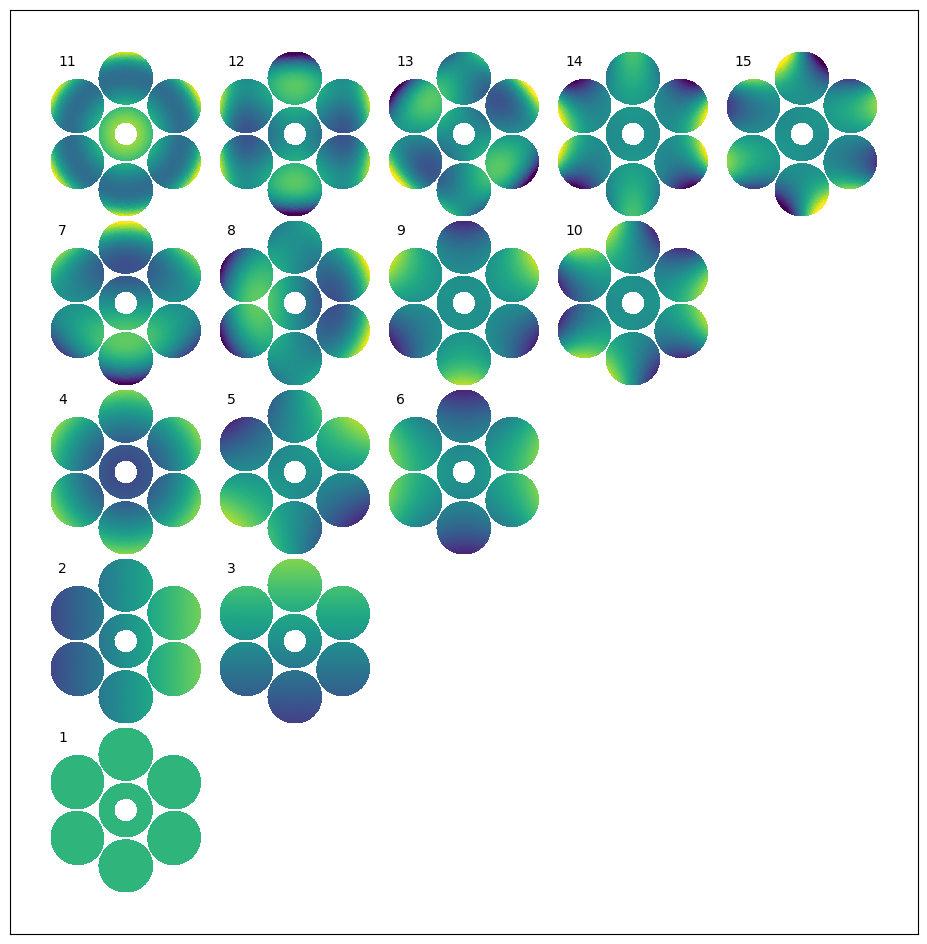

In [47]:
fig, ax =plt.subplots(figsize=(12,12))
vmin = np.min(modes[7,:])
vmax = np.max(modes[7,:])
l = 3
k = 0
for i in range(6):
    for j in range(i):
        for sid in range(1,8):
            m = sids==sid
            xo = j*l
            yo = i*l
            if sid==7:
                x = xy[m,0]
                y = xy[m,1]
                #triang00 = tri.Triangulation(x,y)
                triang = tri.Triangulation(x+xo,y+yo)
                triang.set_mask(np.hypot(x[triang.triangles].mean(axis=1),
                         y[triang.triangles].mean(axis=1))
                < 0.21)
                h = ax.tripcolor(triang,modes[k,m],vmin=vmin,vmax=vmax)
            else:
                h = ax.tripcolor(xy[m,0]+xo,xy[m,1]+yo,modes[k,m],vmin=vmin,vmax=vmax)
        k+=1
        ax.text(xo-0.8*l/2,yo+0.8*l/2,f"{k}")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
#fig.colorbar(h,ax=ax)

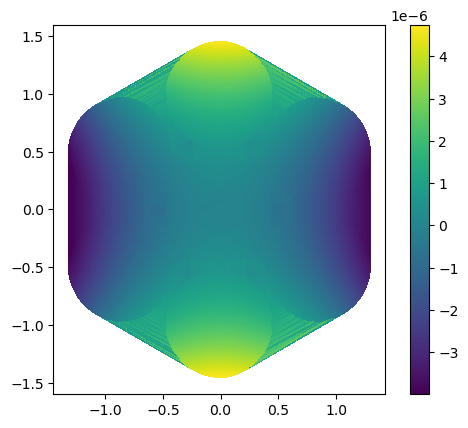

In [8]:
fig, ax =plt.subplots()
h = ax.tripcolor(xy[:,0],xy[:,1],opd)
ax.set_aspect("equal")
fig.colorbar(h,ax=ax)

In [9]:
whos

Variable   Type              Data/Info
--------------------------------------
ax         Axes              Axes(0.226536,0.11;0.518464x0.77)
fig        Figure            Figure(640x480)
h          PolyCollection    <matplotlib.collections.P<...>object at 0x70d001b62310>
modes      ndarray           15x137339: 2060085 elems, type `float64`, 16480680 bytes (15.717201232910156 Mb)
np         module            <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
opd        ndarray           137339: 137339 elems, type `float64`, 1098712 bytes (1.0478134155273438 Mb)
plt        module            <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
tri        module            <module 'matplotlib.tri' <...>plotlib/tri/__init__.py'>
xy         ndarray           137339x2: 274678 elems, type `float64`, 2197424 bytes (2.0956268310546875 Mb)
zernp      dict              n=3
